In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('train.csv',usecols=['Survived','Age','Fare'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [8]:
df['Age_imputed']=df['Age']

In [9]:
df

,Survived,Age,Fare,Age_imputed
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0
...,...,...,...,...
886,0,27.0,13.0000,27.0
887,1,19.0,30.0000,19.0
888,0,NaN,23.4500,NaN
889,1,26.0,30.0000,26.0


In [13]:
df['Age_imputed'][df['Age_imputed'].isnull()]

5     NaN
17    NaN
19    NaN
26    NaN
28    NaN
       ..
859   NaN
863   NaN
868   NaN
878   NaN
888   NaN
Name: Age_imputed, Length: 177, dtype: float64

In [27]:
df['Age'].dropna().sample(df['Age'].isnull().sum()).values

array([ 4.  , 22.  , 20.  , 22.  , 40.  ,  2.  , 33.  , 56.  , 60.  ,
       32.  , 29.  , 44.  , 22.  , 44.  , 16.  , 18.  , 31.  , 36.  ,
       18.  , 21.  , 27.  ,  1.  , 16.  ,  0.75, 24.  , 38.  , 36.  ,
       18.  , 22.  , 20.  , 63.  , 36.  , 46.  ,  1.  , 19.  ,  4.  ,
       36.  , 21.  , 30.5 , 43.  , 29.  , 39.  , 32.  , 16.  , 43.  ,
       18.  , 37.  , 28.  , 32.  , 31.  , 11.  , 35.  , 41.  , 20.  ,
       52.  ,  6.  , 21.  , 44.  , 54.  , 40.  , 22.  , 29.  , 33.  ,
       56.  , 58.  , 16.  , 24.  , 27.  , 39.  , 62.  , 17.  , 48.  ,
       30.  , 15.  , 65.  , 13.  , 36.  , 18.  , 28.  , 16.  , 33.  ,
       33.  , 38.  , 36.  , 38.  , 49.  , 42.  , 25.  , 54.  ,  5.  ,
       35.  , 25.  , 38.  , 16.  , 51.  , 22.  , 28.  , 35.  , 31.  ,
       26.  , 30.  , 27.  , 71.  , 55.  , 39.  , 16.  , 40.  , 33.  ,
       24.  ,  5.  , 35.  , 32.  , 59.  , 37.  , 19.  , 24.  , 23.  ,
       42.  , 21.  , 16.  , 23.  , 18.  ,  2.  , 54.  , 55.  ,  2.  ,
       42.  , 19.  ,

In [28]:
df['Age_imputed'][df['Age_imputed'].isnull()]=df['Age'].dropna().sample(df['Age'].isnull().sum()).values
df.head()

/var/folders/dp/dp6ccyk50v5cf3723z69p3gr0000gn/T/ipykernel_3308/282705930.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Age_imputed'][df['Age_imputed'].isnull()]=df['Age'].dropna().sample(df['Age'].isnull().sum()).values
/var/folde

,Survived,Age,Fare,Age_imputed
0,0,22.0,7.2500,22.0
1,1,38.0,71.2833,38.0
2,1,26.0,7.9250,26.0
3,1,35.0,53.1000,35.0
4,0,35.0,8.0500,35.0


In [29]:
df.isnull().sum()

Survived         0
Age            177
Fare             0
Age_imputed      0
dtype: int64

/var/folders/dp/dp6ccyk50v5cf3723z69p3gr0000gn/T/ipykernel_3308/3171256237.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'],label='original',hist=False)
/var/folders/dp/dp6ccyk50v5cf3723z69p3gr0000gn/T/ipykernel_3308/3171256237.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



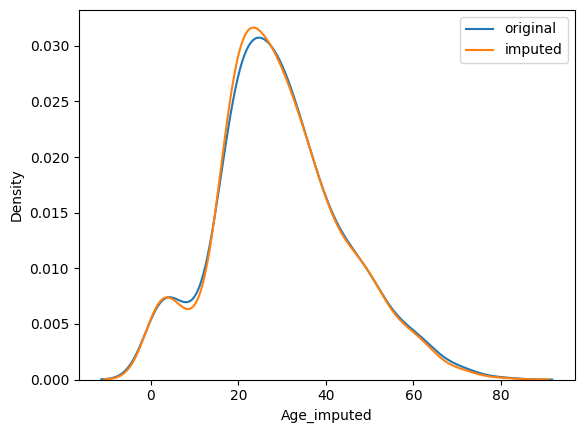

In [37]:
sns.distplot(df['Age'],label='original',hist=False)
sns.distplot(df['Age_imputed'],label='imputed',hist=False)
plt.legend()
plt.show()

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=2)

In [41]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,35.0
493,71.0,49.5042,71.0
527,NaN,221.7792,38.0


In [42]:
X_test

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0
...,...,...,...
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,42.0
870,26.0,7.8958,26.0
